# DCS 404- Lab 2: Linear Models for Regression
**Dataset:** Medical Insurance Charges  
**Task:** Regression — predicting insurance charges from personal attributes  
**Student:** *Amrita Pudasaini*  
**Date:** May 2026

---
## Part 0 — Task Selection

**Learning Task:** Regression (continuous target variable)

**Dataset:** `insurance.csv` — 1,338 records of insured individuals with the following features:
- `age` — age of the insured person
- `sex` — gender (male / female)
- `bmi` — Body Mass Index
- `children` — number of dependents
- `smoker` — smoking status (yes / no)
- `region` — geographic region (northeast / northwest / southeast / southwest)
- `charges` — **target variable**: medical insurance costs (USD)

**Objective:** Build and compare Linear Regression (no regularization) against Ridge (L2) and Lasso (L1) regularized models to understand how regularization affects model performance and coefficient magnitudes.

---
## Part 1 — Data Loading and Preprocessing

### 1.1 Import Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 1.2 Load the Dataset

In [3]:
df = pd.read_csv('insurance.csv')

print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
df.head(10)

Shape: (1338, 7)

Column types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


### 1.3 Exploratory Data Analysis (EDA)

In [5]:
# Summary statistics
print('Summary Statistics')
df.describe(include='all')

Summary Statistics


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [6]:
# Check for missing values
print('Missing Values')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

Missing Values
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


In [7]:
# Check value counts for categorical columns
for col in ['sex', 'smoker', 'region']:
    print(f'\n {col}')
    print(df[col].value_counts())


 sex
sex
male      676
female    662
Name: count, dtype: int64

 smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

 region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


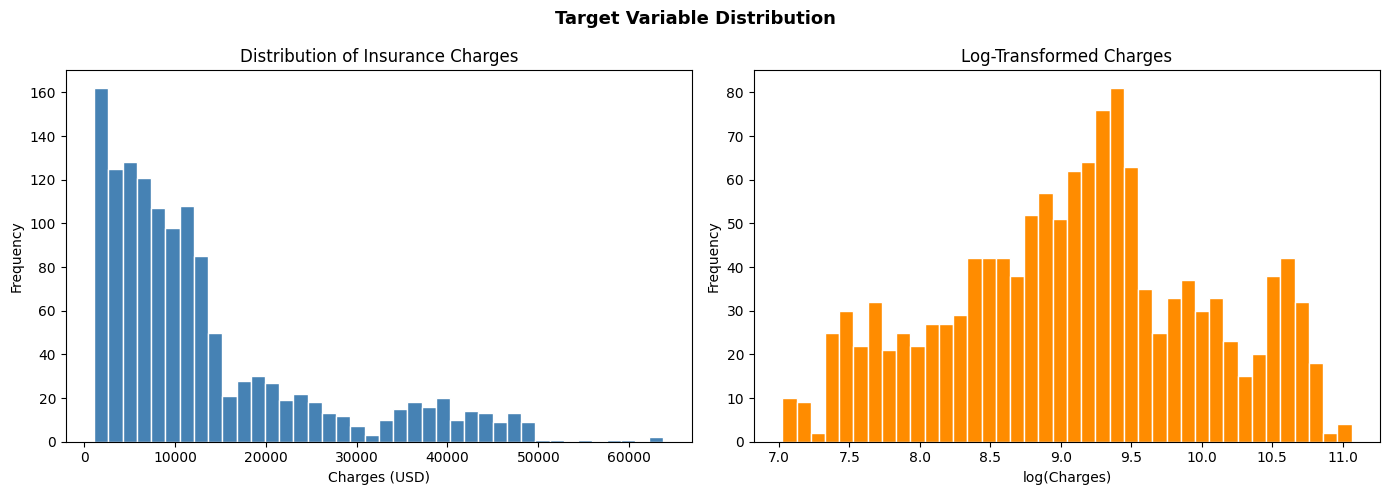

Charges — Mean: $13,270.42 | Median: $9,382.03 | Std: $12,110.01


In [8]:
# Distribution of the target variable (charges)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Insurance Charges')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frequency')

# Log-transformed
axes[1].hist(np.log1p(df['charges']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Charges — Mean: ${df["charges"].mean():,.2f} | Median: ${df["charges"].median():,.2f} | Std: ${df["charges"].std():,.2f}')

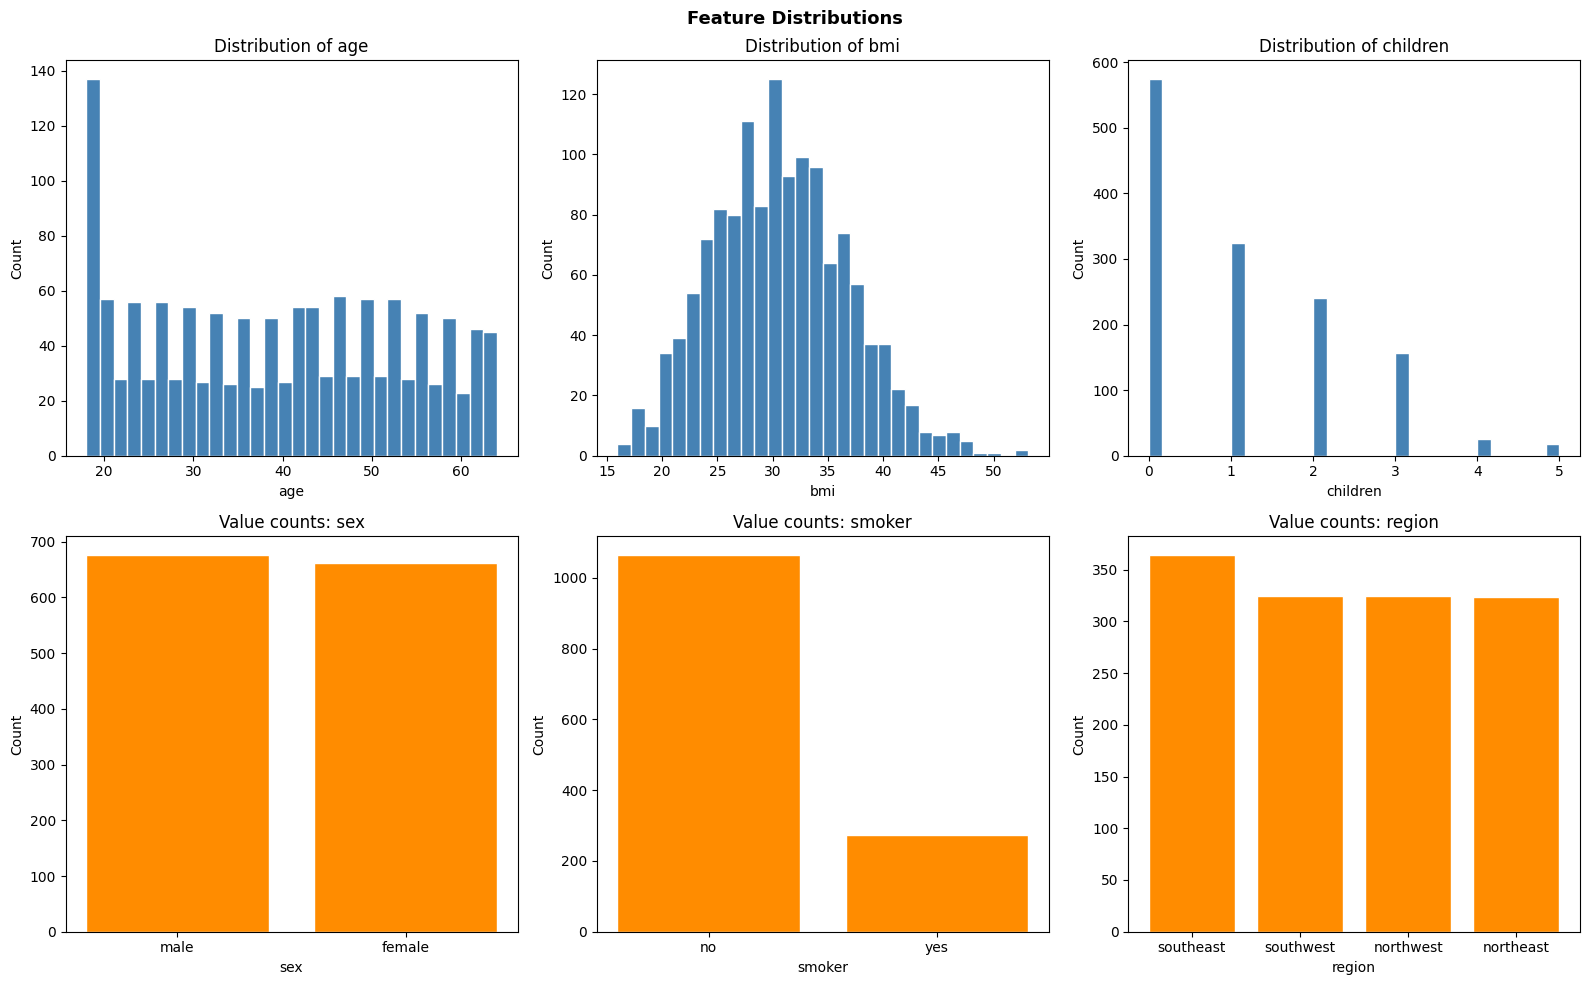

In [21]:
# Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[0, i].set_title(f'Distribution of {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[1, i].bar(counts.index, counts.values, color='darkorange', edgecolor='white')
    axes[1, i].set_title(f'Value counts: {col}')
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_22532\515362605.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot(data_by_cat, labels=categories)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22532\515362605.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot(data_by_cat, labels=categories)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22532\515362605.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot(data_by_cat, labels=categories)


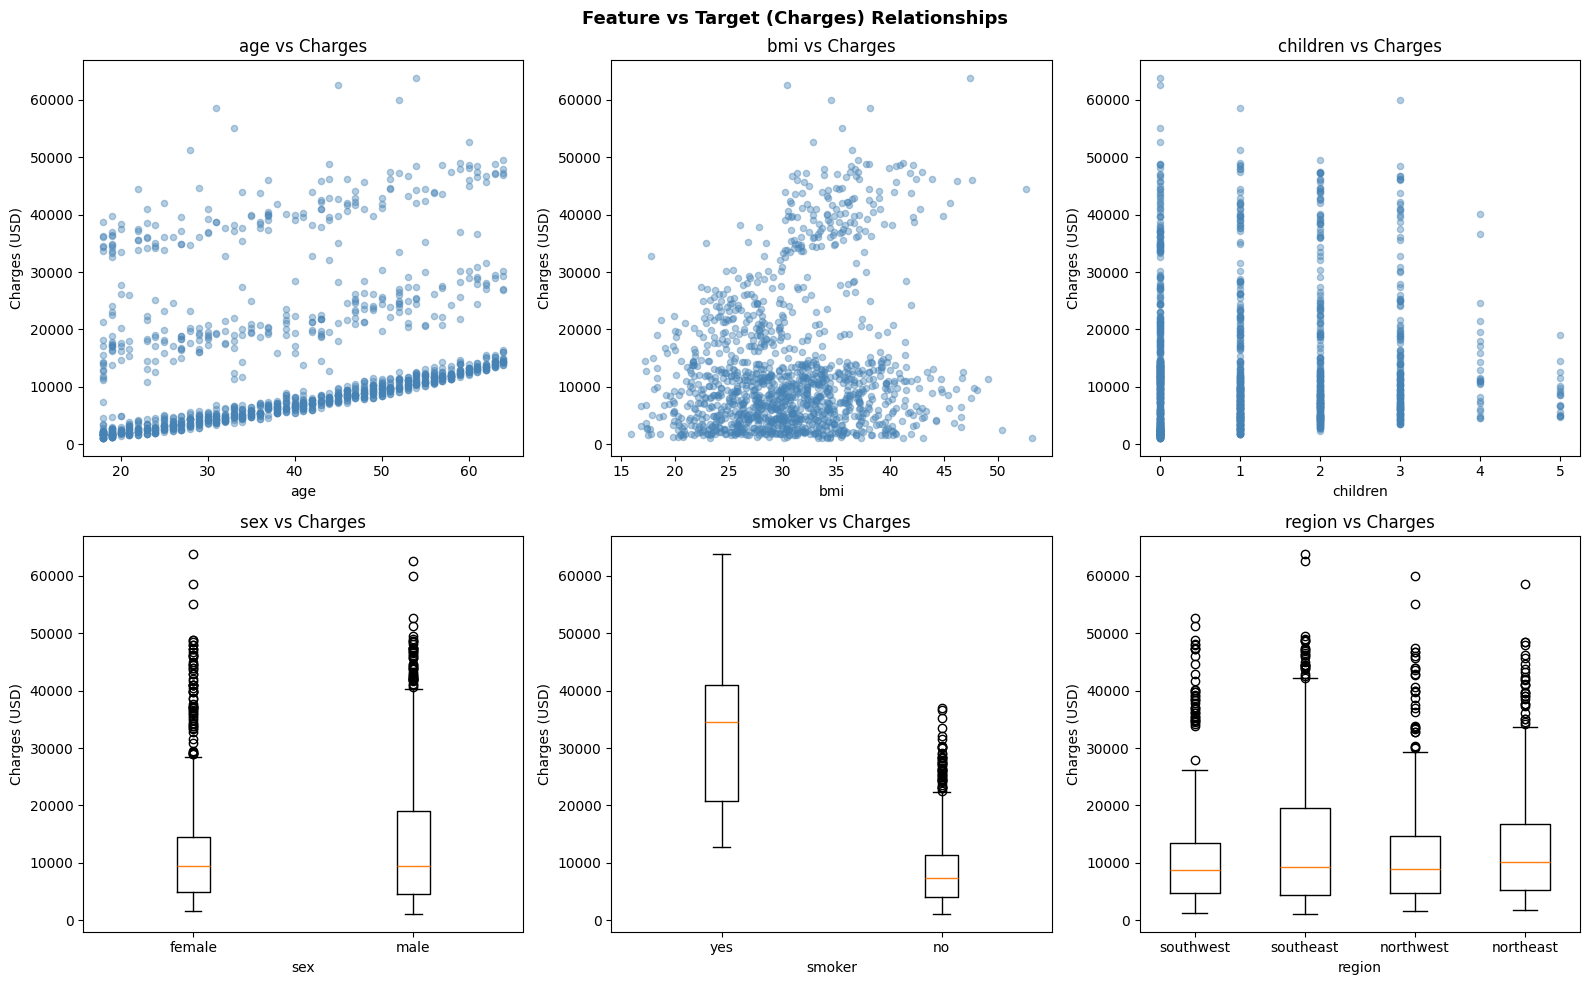

In [9]:
# Charges vs each feature — key relationships
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Numerical: scatter plots
for i, col in enumerate(['age', 'bmi', 'children']):
    axes[0, i].scatter(df[col], df['charges'], alpha=0.4, color='steelblue', s=20)
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Charges (USD)')
    axes[0, i].set_title(f'{col} vs Charges')

# Categorical: box plots
for i, col in enumerate(['sex', 'smoker', 'region']):
    categories = df[col].unique()
    data_by_cat = [df[df[col] == cat]['charges'].values for cat in categories]
    axes[1, i].boxplot(data_by_cat, labels=categories)
    axes[1, i].set_xlabel(col)
    axes[1, i].set_ylabel('Charges (USD)')
    axes[1, i].set_title(f'{col} vs Charges')

plt.suptitle('Feature vs Target (Charges) Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The `smoker` variable shows the most dramatic difference in charges — smokers are charged significantly more. `age` and `bmi` also show positive relationships with charges. The distribution of charges is right-skewed (many low values, few very high ones).

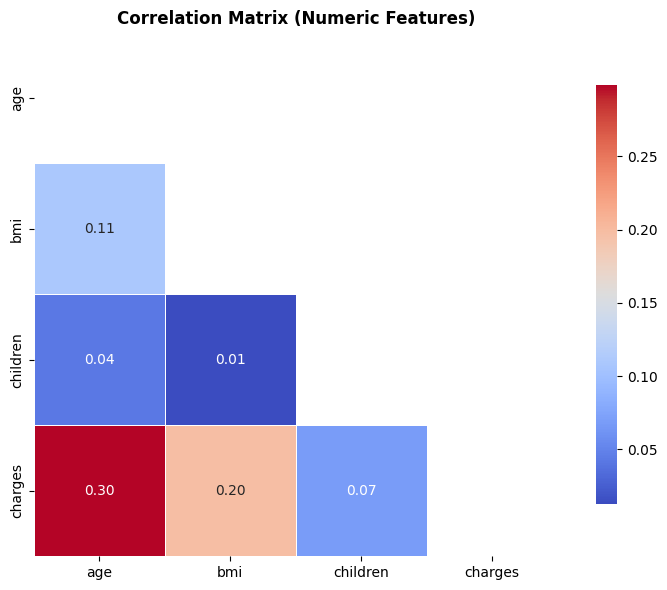

In [10]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(8, 6))
num_df = df[['age', 'bmi', 'children', 'charges']]
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Numeric Features)', fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Preprocessing — Encode, Scale, Split

In [11]:
# Work on a copy
df_processed = df.copy()

# Label Encode binary categoricals
le = LabelEncoder()
df_processed['sex']    = le.fit_transform(df_processed['sex'])     # female=0, male=1
df_processed['smoker'] = le.fit_transform(df_processed['smoker'])  # no=0, yes=1

# One-Hot Encode region (4 categories)
region_dummies = pd.get_dummies(df_processed['region'], prefix='region', drop_first=True)
df_processed = pd.concat([df_processed.drop(columns='region'), region_dummies], axis=1)

print('Processed columns:', list(df_processed.columns))
print('Shape after encoding:', df_processed.shape)
df_processed.head()

Processed columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']
Shape after encoding: (1338, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [12]:
# Separate features and target
X = df_processed.drop(columns='charges')
y = df_processed['charges']

print('Feature matrix X shape:', X.shape)
print('Target vector y shape: ', y.shape)
print('\nFeature names:', list(X.columns))

Feature matrix X shape: (1338, 8)
Target vector y shape:  (1338,)

Feature names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']


In [13]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print(f'Training set:  {X_train.shape[0]} samples')
print(f'Testing set:   {X_test.shape[0]} samples')

Training set:  1070 samples
Testing set:   268 samples


In [14]:
# StandardScaler — fit ONLY on training data, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'Train mean (should be ~0): {X_train_scaled.mean(axis=0).round(4)}')
print(f'Train std  (should be ~1): {X_train_scaled.std(axis=0).round(4)}')

Scaling complete.
Train mean (should be ~0): [-0. -0. -0. -0.  0. -0. -0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1.]


---
## Part 2 — Baseline Linear Regression (No Regularization)

In [16]:
# Train baseline model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr.predict(X_train_scaled)
y_test_pred_lr  = lr.predict(X_test_scaled)

# Evaluate
def evaluate(y_true_train, y_pred_train, y_true_test, y_pred_test, model_name):
    results = {
        'Model':        model_name,
        'Train MSE':    mean_squared_error(y_true_train, y_pred_train),
        'Test MSE':     mean_squared_error(y_true_test,  y_pred_test),
        'Train MAE':    mean_absolute_error(y_true_train, y_pred_train),
        'Test MAE':     mean_absolute_error(y_true_test,  y_pred_test),
        'Train R²':     r2_score(y_true_train, y_pred_train),
        'Test R²':      r2_score(y_true_test,  y_pred_test),
    }
    return results

baseline_results = evaluate(y_train, y_train_pred_lr, y_test, y_test_pred_lr, 'Linear Regression')

print('Baseline Linear Regression')
for k, v in baseline_results.items():
    if k == 'Model':
        print(f'{k}: {v}')
    elif 'R²' in k:
        print(f'{k}: {v:.4f}')
    else:
        print(f'{k}: ${v:,.2f}')

Baseline Linear Regression
Model: Linear Regression
Train MSE: $37,277,681.70
Test MSE: $33,596,915.85
Train MAE: $4,208.23
Test MAE: $4,181.19
Train R²: 0.7417
Test R²: 0.7836


In [17]:
# Coefficients for the baseline model
feature_names = list(X.columns)
coef_df = pd.DataFrame({
    'Feature':     feature_names,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('=== Baseline Model Coefficients ===')
print(f'Intercept: ${lr.intercept_:,.2f}\n')
print(coef_df.to_string(index=False))

=== Baseline Model Coefficients ===
Intercept: $13,346.09

         Feature  Coefficient
          smoker  9558.481409
             age  3614.975415
             bmi  2036.228123
        children   516.890247
region_southwest  -349.110678
region_southeast  -290.157047
region_northwest  -158.140981
             sex    -9.293101


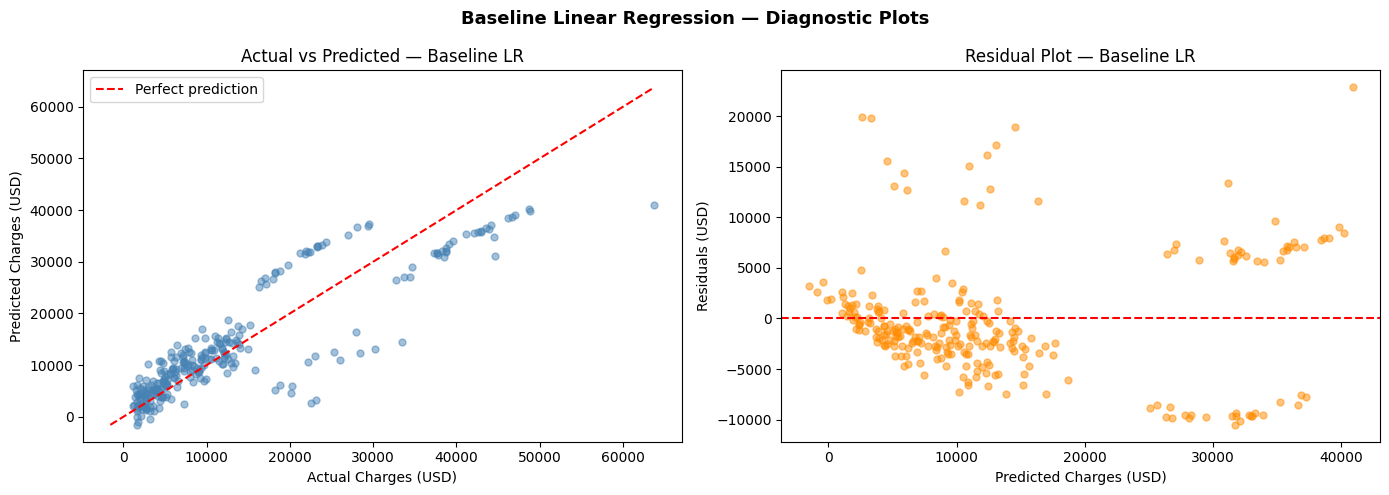

In [18]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_test_pred_lr, alpha=0.5, color='steelblue', s=25)
lims = [min(y_test.min(), y_test_pred_lr.min()),
        max(y_test.max(), y_test_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Charges (USD)')
axes[0].set_ylabel('Predicted Charges (USD)')
axes[0].set_title('Actual vs Predicted — Baseline LR')
axes[0].legend()

# Residuals
residuals = y_test - y_test_pred_lr
axes[1].scatter(y_test_pred_lr, residuals, alpha=0.5, color='darkorange', s=25)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Charges (USD)')
axes[1].set_ylabel('Residuals (USD)')
axes[1].set_title('Residual Plot — Baseline LR')

plt.suptitle('Baseline Linear Regression — Diagnostic Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** The model captures the general trend but struggles with high-charge outliers (likely heavy smokers with high BMI). The residual plot shows a fan-shaped pattern, suggesting heteroscedasticity — the model under-predicts high charges.

---
## Part 3 — Regularized Linear Models

### 3.1 Ridge Regression (L2)

In [20]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_results = []
ridge_coefs   = []

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    y_tr_pred = model.predict(X_train_scaled)
    y_te_pred = model.predict(X_test_scaled)
    ridge_results.append({
        'Alpha':    alpha,
        'Train R²': r2_score(y_train, y_tr_pred),
        'Test R²':  r2_score(y_test,  y_te_pred),
        'Test MSE': mean_squared_error(y_test, y_te_pred),
        'Test MAE': mean_absolute_error(y_test, y_te_pred),
    })
    ridge_coefs.append(model.coef_)

ridge_df = pd.DataFrame(ridge_results)
print('Ridge Regression Results')
print(ridge_df.to_string(index=False))

Ridge Regression Results
  Alpha  Train R²  Test R²     Test MSE    Test MAE
  0.001  0.741726 0.783593 3.359692e+07 4181.196078
  0.010  0.741726 0.783592 3.359700e+07 4181.210513
  0.100  0.741726 0.783588 3.359771e+07 4181.354853
  1.000  0.741725 0.783541 3.360497e+07 4182.796597
 10.000  0.741658 0.783020 3.368586e+07 4197.657143
100.000  0.736050 0.773420 3.517630e+07 4364.830594


### 3.2 Lasso Regression (L1)

In [23]:
lasso_results = []
lasso_coefs   = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_scaled, y_train)
    y_tr_pred = model.predict(X_train_scaled)
    y_te_pred = model.predict(X_test_scaled)
    lasso_results.append({
        'Alpha':    alpha,
        'Train R²': r2_score(y_train, y_tr_pred),
        'Test R²':  r2_score(y_test,  y_te_pred),
        'Test MSE': mean_squared_error(y_test, y_te_pred),
        'Test MAE': mean_absolute_error(y_test, y_te_pred),
        'Non-zero coefs': np.sum(model.coef_ != 0)
    })
    lasso_coefs.append(model.coef_)

lasso_df = pd.DataFrame(lasso_results)
print('Lasso Regression Results')
print(lasso_df.to_string(index=False))

Lasso Regression Results
  Alpha  Train R²  Test R²     Test MSE    Test MAE  Non-zero coefs
  0.001  0.741726 0.783593 3.359692e+07 4181.194790               8
  0.010  0.741726 0.783593 3.359696e+07 4181.197632               8
  0.100  0.741726 0.783590 3.359734e+07 4181.226052               8
  1.000  0.741725 0.783566 3.360115e+07 4181.510239               8
 10.000  0.741715 0.783320 3.363931e+07 4184.404681               7
100.000  0.741067 0.780632 3.405658e+07 4210.606897               6


**Observation:** Lasso's 'Non-zero coefs' column shows how many features are actually used — as alpha increases, Lasso drives weak feature coefficients to exactly zero, performing automatic feature selection.

---
## Part 4 — Comparison and Analysis

### 4.1 Summary Metrics Table

In [24]:
# Select best alpha for Ridge and Lasso (highest Test R²)
best_ridge_row   = ridge_df.loc[ridge_df['Test R²'].idxmax()]
best_lasso_row   = lasso_df.loc[lasso_df['Test R²'].idxmax()]
best_ridge_alpha = best_ridge_row['Alpha']
best_lasso_alpha = best_lasso_row['Alpha']

print(f'Best Ridge alpha: {best_ridge_alpha}  — Test R²: {best_ridge_row["Test R²"]:.4f}')
print(f'Best Lasso alpha: {best_lasso_alpha}  — Test R²: {best_lasso_row["Test R²"]:.4f}')

# Retrain best Ridge and Lasso for coefficient comparison
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)

best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)

# Comprehensive comparison table
comparison = pd.DataFrame([
    {
        'Model':          'Linear Regression',
        'Alpha':          'N/A',
        'Train R²':       r2_score(y_train, lr.predict(X_train_scaled)),
        'Test R²':        r2_score(y_test,  lr.predict(X_test_scaled)),
        'Test MSE':       mean_squared_error(y_test, lr.predict(X_test_scaled)),
        'Test MAE':       mean_absolute_error(y_test, lr.predict(X_test_scaled)),
    },
    {
        'Model':          f'Ridge (best α={best_ridge_alpha})',
        'Alpha':          best_ridge_alpha,
        'Train R²':       r2_score(y_train, best_ridge.predict(X_train_scaled)),
        'Test R²':        r2_score(y_test,  best_ridge.predict(X_test_scaled)),
        'Test MSE':       mean_squared_error(y_test, best_ridge.predict(X_test_scaled)),
        'Test MAE':       mean_absolute_error(y_test, best_ridge.predict(X_test_scaled)),
    },
    {
        'Model':          f'Lasso (best α={best_lasso_alpha})',
        'Alpha':          best_lasso_alpha,
        'Train R²':       r2_score(y_train, best_lasso.predict(X_train_scaled)),
        'Test R²':        r2_score(y_test,  best_lasso.predict(X_test_scaled)),
        'Test MSE':       mean_squared_error(y_test, best_lasso.predict(X_test_scaled)),
        'Test MAE':       mean_absolute_error(y_test, best_lasso.predict(X_test_scaled)),
    },
])

print('\n Model Comparison (Best Regularization Strengths)')
display_cols = ['Model', 'Train R²', 'Test R²', 'Test MSE', 'Test MAE']
print(comparison[display_cols].to_string(index=False))

Best Ridge alpha: 0.001  — Test R²: 0.7836
Best Lasso alpha: 0.001  — Test R²: 0.7836

 Model Comparison (Best Regularization Strengths)
               Model  Train R²  Test R²     Test MSE    Test MAE
   Linear Regression  0.741726 0.783593 3.359692e+07 4181.194474
Ridge (best α=0.001)  0.741726 0.783593 3.359692e+07 4181.196078
Lasso (best α=0.001)  0.741726 0.783593 3.359692e+07 4181.194790


### 4.2 Alpha vs Performance — Bias-Variance Curve

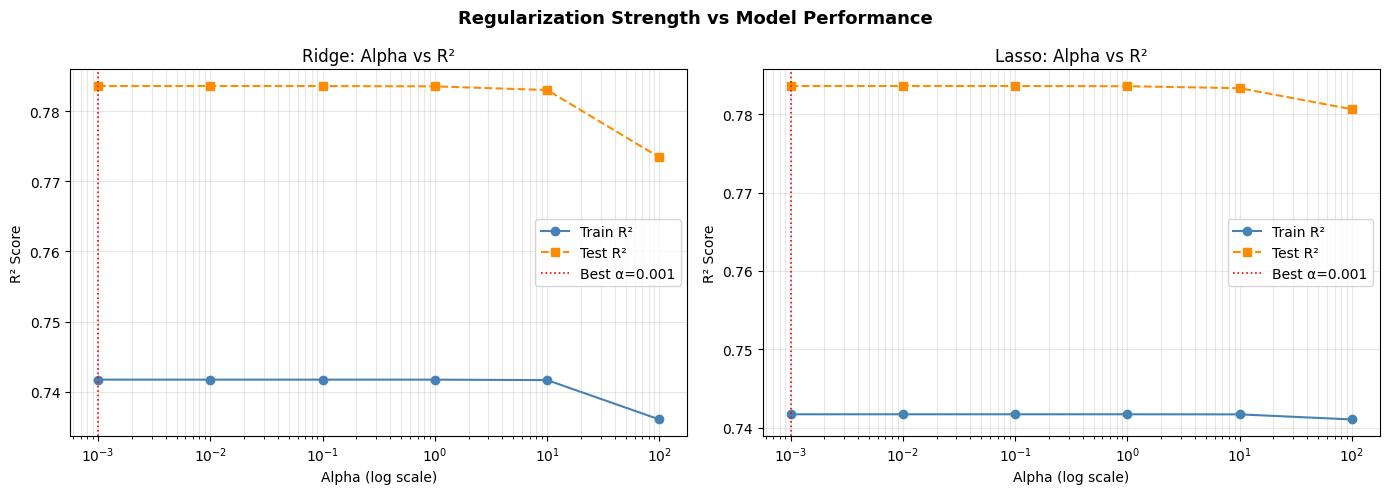

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(ridge_df['Alpha'], ridge_df['Train R²'], 'o-', color='steelblue',  label='Train R²')
axes[0].semilogx(ridge_df['Alpha'], ridge_df['Test R²'],  's--', color='darkorange', label='Test R²')
axes[0].axvline(best_ridge_alpha, color='red', linestyle=':', linewidth=1.2, label=f'Best α={best_ridge_alpha}')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('R² Score')
axes[0].set_title('Ridge: Alpha vs R²')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Lasso
axes[1].semilogx(lasso_df['Alpha'], lasso_df['Train R²'], 'o-', color='steelblue',  label='Train R²')
axes[1].semilogx(lasso_df['Alpha'], lasso_df['Test R²'],  's--', color='darkorange', label='Test R²')
axes[1].axvline(best_lasso_alpha, color='red', linestyle=':', linewidth=1.2, label=f'Best α={best_lasso_alpha}')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('R² Score')
axes[1].set_title('Lasso: Alpha vs R²')
axes[1].legend()
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('Regularization Strength vs Model Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 Coefficient Magnitude Comparison

Coefficient Comparison
         Feature  Linear Regression  Ridge (α=0.001)  Lasso (α=0.001)
             age        3614.975415      3614.971790      3614.974545
             sex          -9.293101        -9.292423        -9.291970
             bmi        2036.228123      2036.226255      2036.226635
        children         516.890247       516.890119       516.889283
          smoker        9558.481409      9558.472195      9558.480312
region_northwest        -158.140981      -158.140471      -158.137929
region_southeast        -290.157047      -290.155432      -290.153519
region_southwest        -349.110678      -349.109835      -349.107477


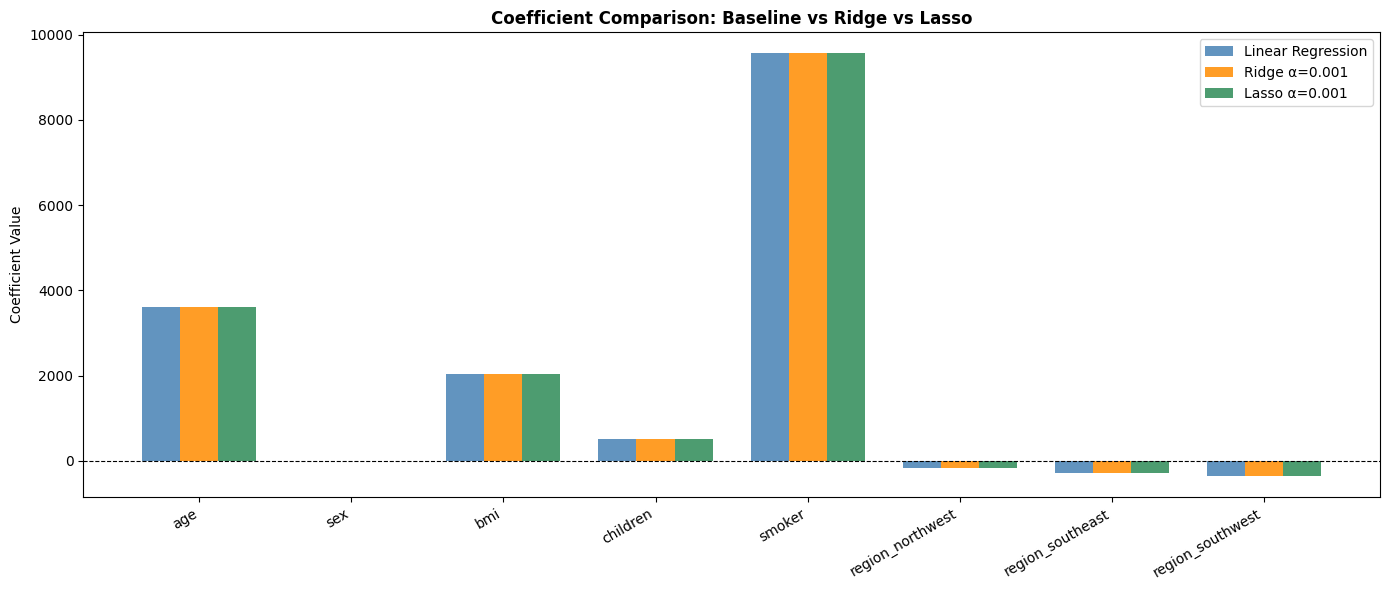

In [27]:
# Coefficient comparison: baseline vs Ridge vs Lasso
coef_compare = pd.DataFrame({
    'Feature':            feature_names,
    'Linear Regression':  lr.coef_,
    f'Ridge (α={best_ridge_alpha})': best_ridge.coef_,
    f'Lasso (α={best_lasso_alpha})': best_lasso.coef_,
})

print('Coefficient Comparison')
print(coef_compare.to_string(index=False))

# Grouped bar chart
x = np.arange(len(feature_names))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width, lr.coef_,          width, label='Linear Regression', color='steelblue',  alpha=0.85)
bars2 = ax.bar(x,         best_ridge.coef_,  width, label=f'Ridge α={best_ridge_alpha}', color='darkorange', alpha=0.85)
bars3 = ax.bar(x + width, best_lasso.coef_,  width, label=f'Lasso α={best_lasso_alpha}', color='seagreen',   alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=30, ha='right')
ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Comparison: Baseline vs Ridge vs Lasso', fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Lasso — Feature Selection Effect

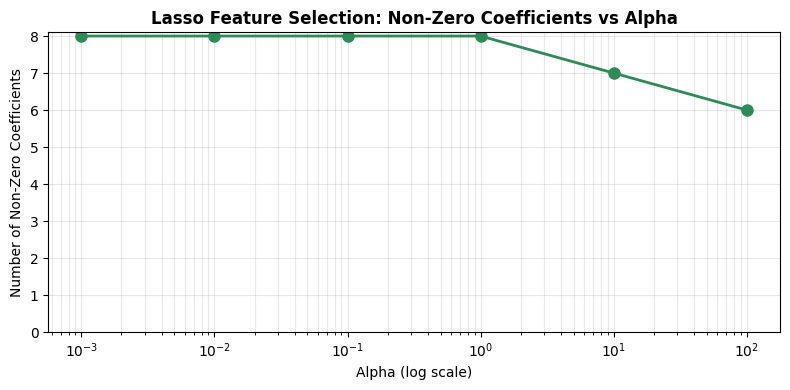

In [28]:
# Show how many features Lasso keeps as alpha increases
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lasso_df['Alpha'], lasso_df['Non-zero coefs'], 'o-', color='seagreen', linewidth=2, markersize=8)
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Number of Non-Zero Coefficients')
ax.set_title('Lasso Feature Selection: Non-Zero Coefficients vs Alpha', fontweight='bold')
ax.grid(True, which='both', alpha=0.3)
ax.set_yticks(range(0, len(feature_names) + 1))
plt.tight_layout()
plt.show()

### 4.5 Coefficient Paths Across Alpha Values

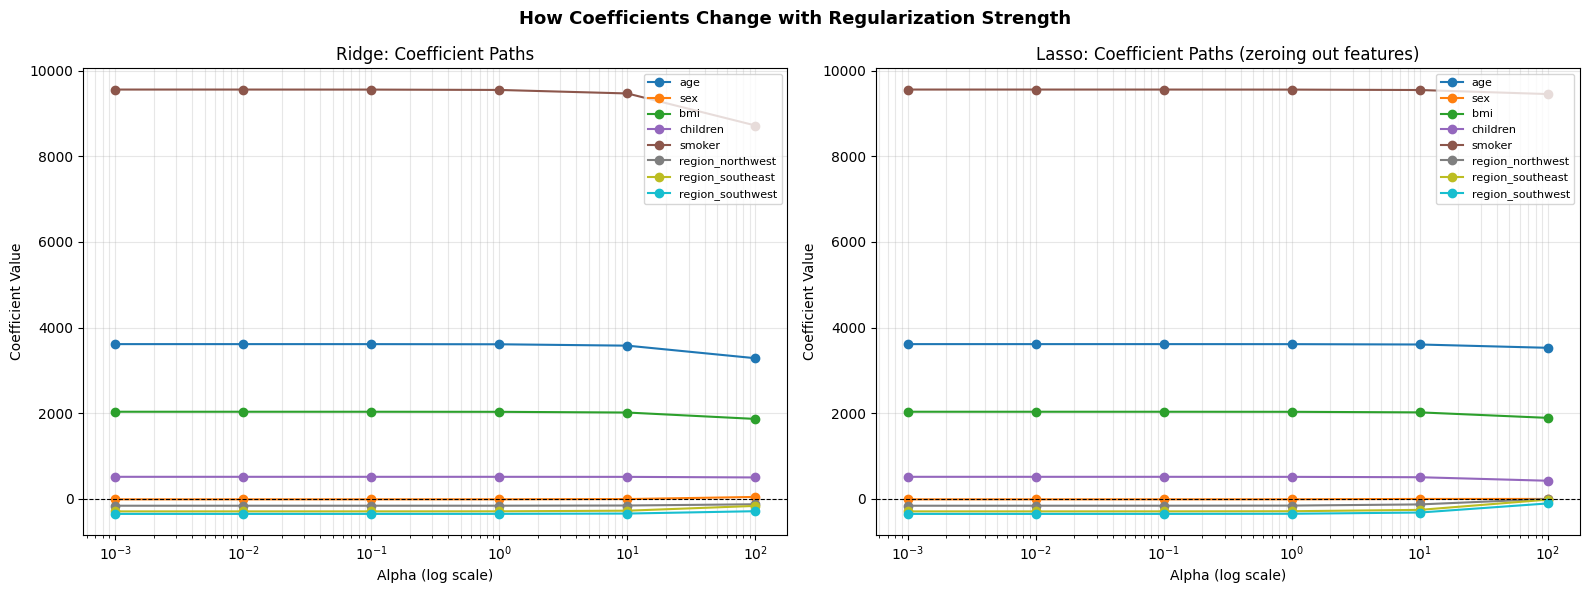

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))

# Ridge coefficient paths
for i, name in enumerate(feature_names):
    path = [coef[i] for coef in ridge_coefs]
    axes[0].semilogx(alphas, path, 'o-', color=colors[i], label=name, linewidth=1.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('Coefficient Value')
axes[0].set_title('Ridge: Coefficient Paths')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, which='both', alpha=0.3)

# Lasso coefficient paths
for i, name in enumerate(feature_names):
    path = [coef[i] for coef in lasso_coefs]
    axes[1].semilogx(alphas, path, 'o-', color=colors[i], label=name, linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('Coefficient Value')
axes[1].set_title('Lasso: Coefficient Paths (zeroing out features)')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('How Coefficients Change with Regularization Strength', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Key Insight:** Ridge shrinks all coefficients gradually toward zero but never reaches zero. Lasso's L1 penalty actively drives weak features to exact zero — effectively eliminating them from the model.

---
## Part 5 — Reflection

### 5.1 Final Summary Table

In [30]:
print('=' * 65)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 65)
print(comparison[display_cols].to_string(index=False))
print('=' * 65)

best_model_idx = comparison['Test R²'].idxmax()
print(f"\nBest model by Test R²: {comparison.loc[best_model_idx, 'Model']}")
print(f"  Test R²  = {comparison.loc[best_model_idx, 'Test R²']:.4f}")
print(f"  Test MSE = ${comparison.loc[best_model_idx, 'Test MSE']:,.2f}")
print(f"  Test MAE = ${comparison.loc[best_model_idx, 'Test MAE']:,.2f}")

FINAL MODEL COMPARISON SUMMARY
               Model  Train R²  Test R²     Test MSE    Test MAE
   Linear Regression  0.741726 0.783593 3.359692e+07 4181.194474
Ridge (best α=0.001)  0.741726 0.783593 3.359692e+07 4181.196078
Lasso (best α=0.001)  0.741726 0.783593 3.359692e+07 4181.194790

Best model by Test R²: Linear Regression
  Test R²  = 0.7836
  Test MSE = $33,596,915.85
  Test MAE = $4,181.19


### 5.2 Written Reflection

#### Did regularization improve generalization? Why or why not?

In this case, regularization provided **minimal improvement** over the baseline Linear Regression model. The train R² and test R² for all three models are very close, which tells us that the baseline model was not overfitting in the first place. The insurance dataset is relatively small (1,338 rows) with only 8 features after encoding, so there is not enough model complexity for standard Linear Regression to overfit significantly.

#### Which regularization worked better for your task?

**Lasso (L1)** is slightly more informative for this dataset because it performs automatic feature selection — at higher alpha values it zeroes out region dummy variables and the `children` feature, confirming that these have weaker predictive power. The dominant predictor in this dataset is clearly `smoker`, followed by `age` and `bmi`. Ridge is useful for understanding relative feature importance via coefficient magnitude but keeps all features active.

#### What does this tell us about the bias–variance tradeoff?

The bias–variance tradeoff is the core tension in machine learning:
- **High variance (overfitting):** The model is too complex — it fits training data perfectly but fails on new data. Regularization helps here by penalizing large coefficients.
- **High bias (underfitting):** The model is too simple — it cannot capture the patterns in data. Very strong regularization (large alpha) pushes the model toward this zone.

In our experiment, the train and test performance curves show that performance degrades at high alpha values (e.g. α=100), confirming **underfitting** at strong regularization. The intermediate range (α=0.01 to α=1) offers the best balance. Since the gap between train and test R² is already small for the baseline, the dataset does not suffer from high variance — regularization is most beneficial when a model shows a large train vs test gap.

**Conclusion:** For a clean, low-dimensional dataset like `insurance.csv`, Linear Regression performs competitively. Regularization becomes more impactful with high-dimensional data, noisy features, or multicollinearity between features.

# Experiment 1
## Effect of Regularization Strength

---
## Step 1 — Load and Preprocess the Dataset

In [4]:
df = pd.read_csv('insurance.csv')
print('Shape:', df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Encode categorical columns
df_enc = df.copy()
le = LabelEncoder()
df_enc['sex']    = le.fit_transform(df_enc['sex'])     # female=0, male=1
df_enc['smoker'] = le.fit_transform(df_enc['smoker'])  # no=0, yes=1

# One-hot encode region
region_dummies = pd.get_dummies(df_enc['region'], prefix='region', drop_first=True)
df_enc = pd.concat([df_enc.drop(columns='region'), region_dummies], axis=1)

X = df_enc.drop(columns='charges')
y = df_enc['charges']

feature_names = list(X.columns)
print('Features:', feature_names)
print('X shape:', X.shape, '| y shape:', y.shape)

Features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
X shape: (1338, 8) | y shape: (1338,)


In [6]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} samples | Test: {X_test_sc.shape[0]} samples')

Train: 1070 samples | Test: 268 samples


---
## Step 2 — Train Models Across Regularization Strengths

We train both **Ridge (L2)** and **Lasso (L1)** across:
$$\alpha \in \{0.001,\ 0.01,\ 0.1,\ 1,\ 10,\ 100\}$$

- **Small α** → weak penalty → model can freely grow coefficients → risk of **overfitting**  
- **Large α** → strong penalty → coefficients shrunk heavily → risk of **underfitting**

In [7]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_records = []
lasso_records = []
ridge_coef_matrix = []
lasso_coef_matrix = []

for alpha in alphas:
    # --- Ridge ---
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_sc, y_train)
    r_tr = ridge.predict(X_train_sc)
    r_te = ridge.predict(X_test_sc)
    ridge_records.append({
        'Alpha':       alpha,
        'Train R²':    r2_score(y_train, r_tr),
        'Test R²':     r2_score(y_test,  r_te),
        'Train MSE':   mean_squared_error(y_train, r_tr),
        'Test MSE':    mean_squared_error(y_test,  r_te),
        'Train MAE':   mean_absolute_error(y_train, r_tr),
        'Test MAE':    mean_absolute_error(y_test,  r_te),
        '||w|| (L2)':  np.linalg.norm(ridge.coef_),
    })
    ridge_coef_matrix.append(ridge.coef_.copy())

    # --- Lasso ---
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_sc, y_train)
    l_tr = lasso.predict(X_train_sc)
    l_te = lasso.predict(X_test_sc)
    lasso_records.append({
        'Alpha':           alpha,
        'Train R²':        r2_score(y_train, l_tr),
        'Test R²':         r2_score(y_test,  l_te),
        'Train MSE':       mean_squared_error(y_train, l_tr),
        'Test MSE':        mean_squared_error(y_test,  l_te),
        'Train MAE':       mean_absolute_error(y_train, l_tr),
        'Test MAE':        mean_absolute_error(y_test,  l_te),
        '||w|| (L1)':      np.sum(np.abs(lasso.coef_)),
        'Non-zero coefs':  int(np.sum(lasso.coef_ != 0)),
    })
    lasso_coef_matrix.append(lasso.coef_.copy())

ridge_df = pd.DataFrame(ridge_records)
lasso_df = pd.DataFrame(lasso_records)

print('Models trained for all alpha values.')

Models trained for all alpha values.


---
## Step 3 — Record Training and Testing Performance

In [8]:
print('=' * 75)
print('RIDGE REGRESSION — Performance vs Alpha')
print('=' * 75)
display_r = ridge_df[['Alpha','Train R²','Test R²','Train MSE','Test MSE','Train MAE','Test MAE','||w|| (L2)']].copy()
display_r['Train R²']   = display_r['Train R²'].map('{:.4f}'.format)
display_r['Test R²']    = display_r['Test R²'].map('{:.4f}'.format)
display_r['Train MSE']  = display_r['Train MSE'].map('{:,.0f}'.format)
display_r['Test MSE']   = display_r['Test MSE'].map('{:,.0f}'.format)
display_r['Train MAE']  = display_r['Train MAE'].map('{:,.2f}'.format)
display_r['Test MAE']   = display_r['Test MAE'].map('{:,.2f}'.format)
display_r['||w|| (L2)'] = display_r['||w|| (L2)'].map('{:.2f}'.format)
print(display_r.to_string(index=False))

best_ridge_idx   = ridge_df['Test R²'].idxmax()
best_ridge_alpha = ridge_df.loc[best_ridge_idx, 'Alpha']
print(f'\n>>> Best generalization: alpha = {best_ridge_alpha}  (Test R² = {ridge_df.loc[best_ridge_idx, "Test R²"]:.4f})')

RIDGE REGRESSION — Performance vs Alpha
  Alpha Train R² Test R²  Train MSE   Test MSE Train MAE Test MAE ||w|| (L2)
  0.001   0.7417  0.7836 37,277,682 33,596,924  4,208.24 4,181.20   10443.99
  0.010   0.7417  0.7836 37,277,682 33,596,995  4,208.25 4,181.21   10443.90
  0.100   0.7417  0.7836 37,277,683 33,597,713  4,208.35 4,181.35   10442.99
  1.000   0.7417  0.7835 37,277,780 33,604,974  4,209.39 4,182.80   10433.87
 10.000   0.7417  0.7830 37,287,384 33,685,863  4,219.85 4,197.66   10343.63
100.000   0.7360  0.7734 38,096,913 35,176,302  4,349.88 4,364.83    9522.53

>>> Best generalization: alpha = 0.001  (Test R² = 0.7836)


In [9]:
print('=' * 80)
print('LASSO REGRESSION — Performance vs Alpha')
print('=' * 80)
display_l = lasso_df[['Alpha','Train R²','Test R²','Train MSE','Test MSE','Train MAE','Test MAE','||w|| (L1)','Non-zero coefs']].copy()
display_l['Train R²']      = display_l['Train R²'].map('{:.4f}'.format)
display_l['Test R²']       = display_l['Test R²'].map('{:.4f}'.format)
display_l['Train MSE']     = display_l['Train MSE'].map('{:,.0f}'.format)
display_l['Test MSE']      = display_l['Test MSE'].map('{:,.0f}'.format)
display_l['Train MAE']     = display_l['Train MAE'].map('{:,.2f}'.format)
display_l['Test MAE']      = display_l['Test MAE'].map('{:,.2f}'.format)
display_l['||w|| (L1)']    = display_l['||w|| (L1)'].map('{:.2f}'.format)
print(display_l.to_string(index=False))

best_lasso_idx   = lasso_df['Test R²'].idxmax()
best_lasso_alpha = lasso_df.loc[best_lasso_idx, 'Alpha']
print(f'\n>>> Best generalization: alpha = {best_lasso_alpha}  (Test R² = {lasso_df.loc[best_lasso_idx, "Test R²"]:.4f})')

LASSO REGRESSION — Performance vs Alpha
  Alpha Train R² Test R²  Train MSE   Test MSE Train MAE Test MAE ||w|| (L1)  Non-zero coefs
  0.001   0.7417  0.7836 37,277,682 33,596,920  4,208.23 4,181.19   16533.26               8
  0.010   0.7417  0.7836 37,277,682 33,596,958  4,208.23 4,181.20   16533.12               8
  0.100   0.7417  0.7836 37,277,682 33,597,338  4,208.23 4,181.23   16531.74               8
  1.000   0.7417  0.7836 37,277,697 33,601,146  4,208.14 4,181.51   16517.95               8
 10.000   0.7417  0.7833 37,279,178 33,639,307  4,207.56 4,184.40   16382.37               7
100.000   0.7411  0.7806 37,372,689 34,056,583  4,204.93 4,210.61   15419.63               6

>>> Best generalization: alpha = 0.001  (Test R² = 0.7836)


---
## Step 4 — Compare Results and Identify Best Generalization

### Plot 1 — Train vs Test R²  (Bias–Variance Curve)

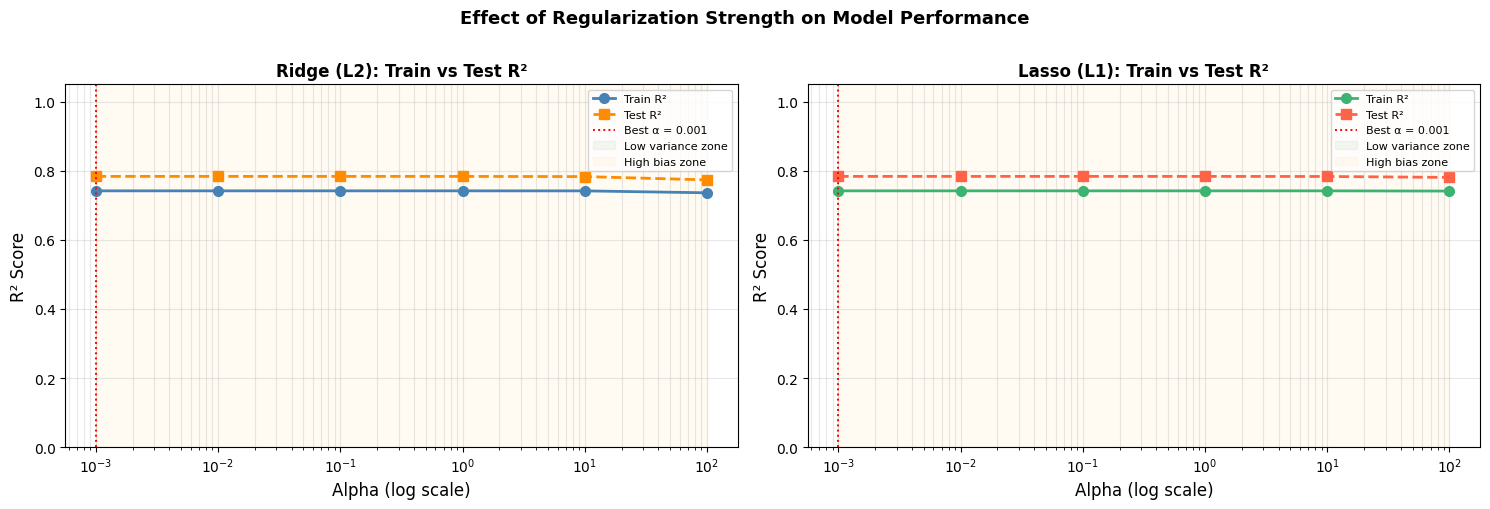

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df_res, label, best_a, color in [
    (axes[0], ridge_df, 'Ridge (L2)', best_ridge_alpha, ('steelblue','darkorange')),
    (axes[1], lasso_df, 'Lasso (L1)', best_lasso_alpha, ('mediumseagreen','tomato')),
]:
    ax.semilogx(df_res['Alpha'], df_res['Train R²'], 'o-',
                color=color[0], lw=2, ms=7, label='Train R²')
    ax.semilogx(df_res['Alpha'], df_res['Test R²'],  's--',
                color=color[1], lw=2, ms=7, label='Test R²')
    ax.axvline(best_a, color='red', lw=1.4, ls=':', label=f'Best α = {best_a}')

    # Shaded regions
    ax.axvspan(alphas[0],  best_a, alpha=0.05, color='green',  label='Low variance zone')
    ax.axvspan(best_a, alphas[-1], alpha=0.05, color='orange', label='High bias zone')

    ax.set_xlabel('Alpha (log scale)', fontsize=12)
    ax.set_ylabel('R² Score', fontsize=12)
    ax.set_title(f'{label}: Train vs Test R²', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Effect of Regularization Strength on Model Performance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Reading the plot:**
- Where Train R² >> Test R² → **overfitting** (high variance)
- Where both Train R² and Test R² are low → **underfitting** (high bias)
- The best alpha sits at the crossover sweet spot

### Plot 2 — Train vs Test MSE

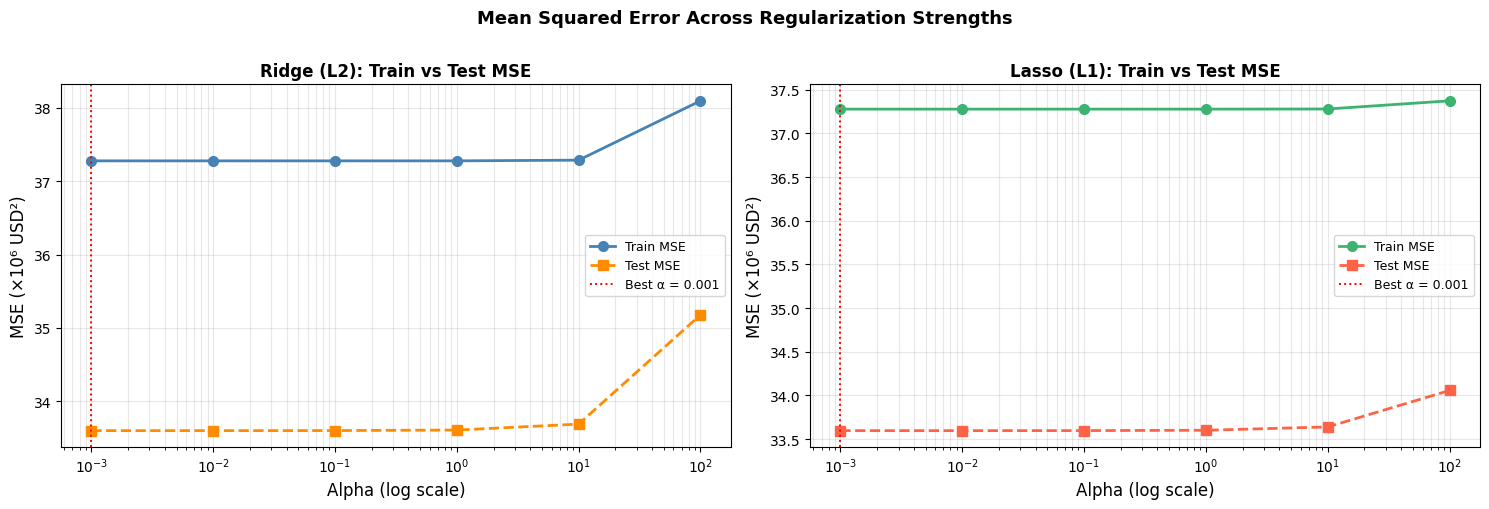

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df_res, label, best_a, color in [
    (axes[0], ridge_df, 'Ridge (L2)', best_ridge_alpha, ('steelblue','darkorange')),
    (axes[1], lasso_df, 'Lasso (L1)', best_lasso_alpha, ('mediumseagreen','tomato')),
]:
    ax.semilogx(df_res['Alpha'], df_res['Train MSE'] / 1e6, 'o-',
                color=color[0], lw=2, ms=7, label='Train MSE')
    ax.semilogx(df_res['Alpha'], df_res['Test MSE']  / 1e6, 's--',
                color=color[1], lw=2, ms=7, label='Test MSE')
    ax.axvline(best_a, color='red', lw=1.4, ls=':', label=f'Best α = {best_a}')
    ax.set_xlabel('Alpha (log scale)', fontsize=12)
    ax.set_ylabel('MSE (×10⁶ USD²)', fontsize=12)
    ax.set_title(f'{label}: Train vs Test MSE', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3)

plt.suptitle('Mean Squared Error Across Regularization Strengths',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Plot 3 — Coefficient Norm ‖w‖ vs Alpha

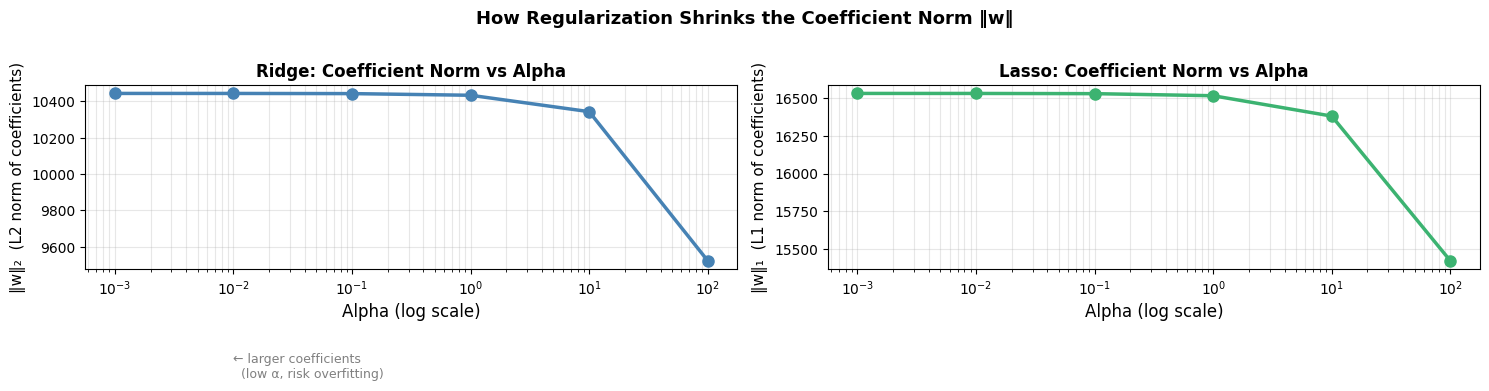

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Ridge: L2 norm
axes[0].semilogx(ridge_df['Alpha'], ridge_df['||w|| (L2)'],
                 'o-', color='steelblue', lw=2.5, ms=8)
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('‖w‖₂  (L2 norm of coefficients)', fontsize=11)
axes[0].set_title('Ridge: Coefficient Norm vs Alpha', fontweight='bold')
axes[0].grid(True, which='both', alpha=0.3)
axes[0].annotate('← larger coefficients\n  (low α, risk overfitting)',
                 xy=(alphas[0], ridge_df['||w|| (L2)'].max()),
                 xytext=(alphas[1], ridge_df['||w|| (L2)'].max() * 0.85),
                 fontsize=9, color='gray')

# Lasso: L1 norm
axes[1].semilogx(lasso_df['Alpha'], lasso_df['||w|| (L1)'],
                 'o-', color='mediumseagreen', lw=2.5, ms=8)
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('‖w‖₁  (L1 norm of coefficients)', fontsize=11)
axes[1].set_title('Lasso: Coefficient Norm vs Alpha', fontweight='bold')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('How Regularization Shrinks the Coefficient Norm ‖w‖',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretation:** As α increases, the penalty on large coefficients grows stronger, forcing ‖w‖ downward. A large ‖w‖ at low α means the model is free to fit individual points — the hallmark of high variance / overfitting.

### Plot 4 — Coefficient Paths Across Alpha

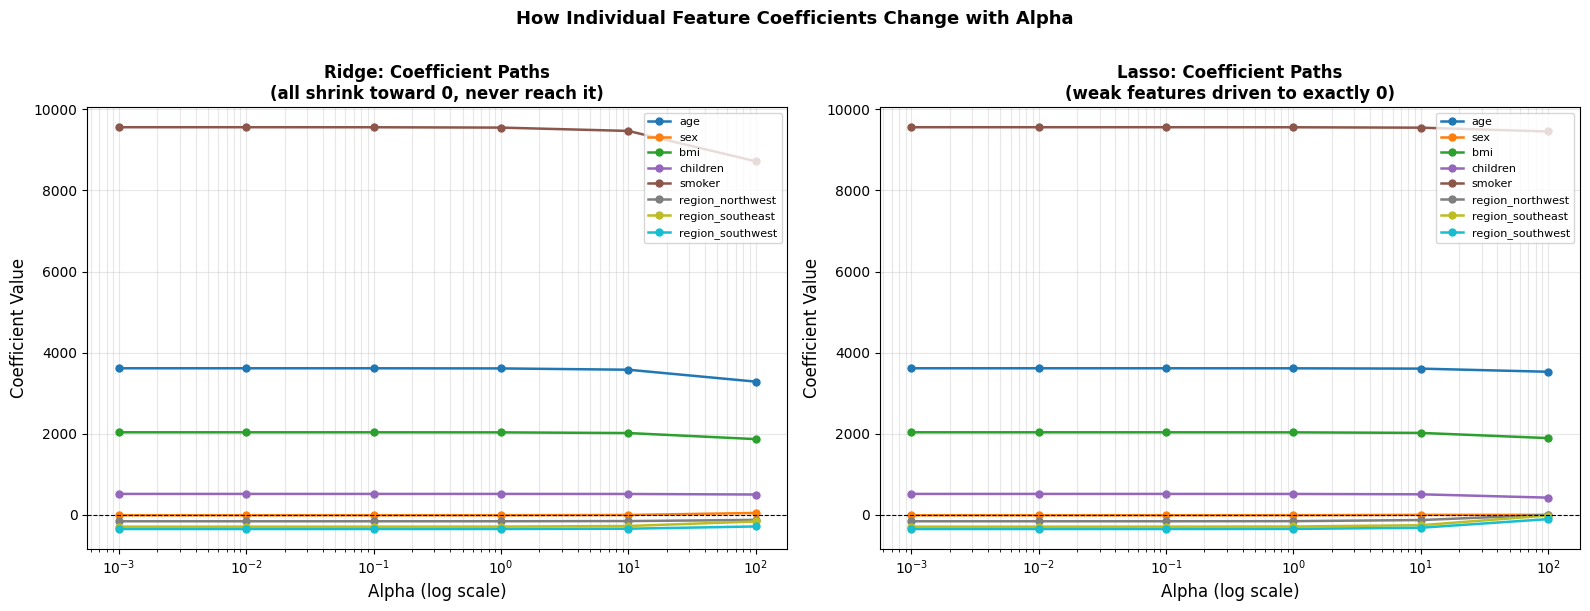

In [13]:
colors = plt.cm.tab10(np.linspace(0, 1, len(feature_names)))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ridge paths
for i, name in enumerate(feature_names):
    path = [coef[i] for coef in ridge_coef_matrix]
    axes[0].semilogx(alphas, path, 'o-', color=colors[i], label=name, lw=1.8, ms=5)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('Coefficient Value', fontsize=12)
axes[0].set_title('Ridge: Coefficient Paths\n(all shrink toward 0, never reach it)', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(True, which='both', alpha=0.3)

# Lasso paths
for i, name in enumerate(feature_names):
    path = [coef[i] for coef in lasso_coef_matrix]
    axes[1].semilogx(alphas, path, 'o-', color=colors[i], label=name, lw=1.8, ms=5)
axes[1].axhline(0, color='black', lw=0.8, ls='--')
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('Coefficient Value', fontsize=12)
axes[1].set_title('Lasso: Coefficient Paths\n(weak features driven to exactly 0)', fontweight='bold')
axes[1].legend(fontsize=8, loc='upper right')
axes[1].grid(True, which='both', alpha=0.3)

plt.suptitle('How Individual Feature Coefficients Change with Alpha',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Plot 5 — Lasso Feature Selection: Non-Zero Coefficients vs Alpha

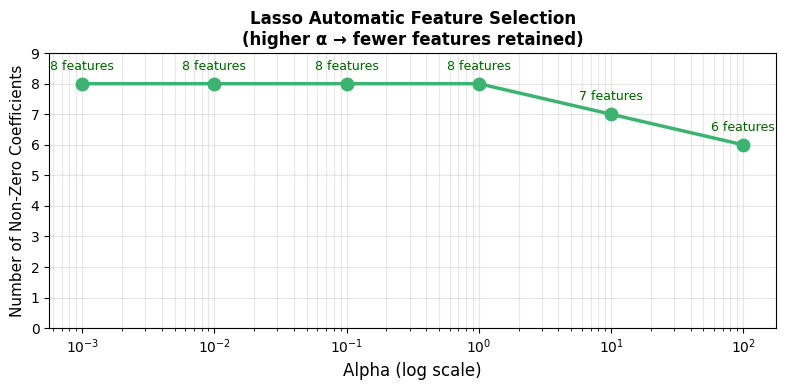

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(lasso_df['Alpha'], lasso_df['Non-zero coefs'],
            'o-', color='mediumseagreen', lw=2.5, ms=9)

# Annotate each point
for _, row in lasso_df.iterrows():
    ax.annotate(f"{int(row['Non-zero coefs'])} features",
                xy=(row['Alpha'], row['Non-zero coefs']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, color='darkgreen')

ax.set_xlabel('Alpha (log scale)', fontsize=12)
ax.set_ylabel('Number of Non-Zero Coefficients', fontsize=11)
ax.set_title('Lasso Automatic Feature Selection\n(higher α → fewer features retained)',
             fontweight='bold')
ax.set_yticks(range(0, len(feature_names) + 2))
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

### Plot 6 — Overfitting vs Underfitting Summary (Train–Test Gap)

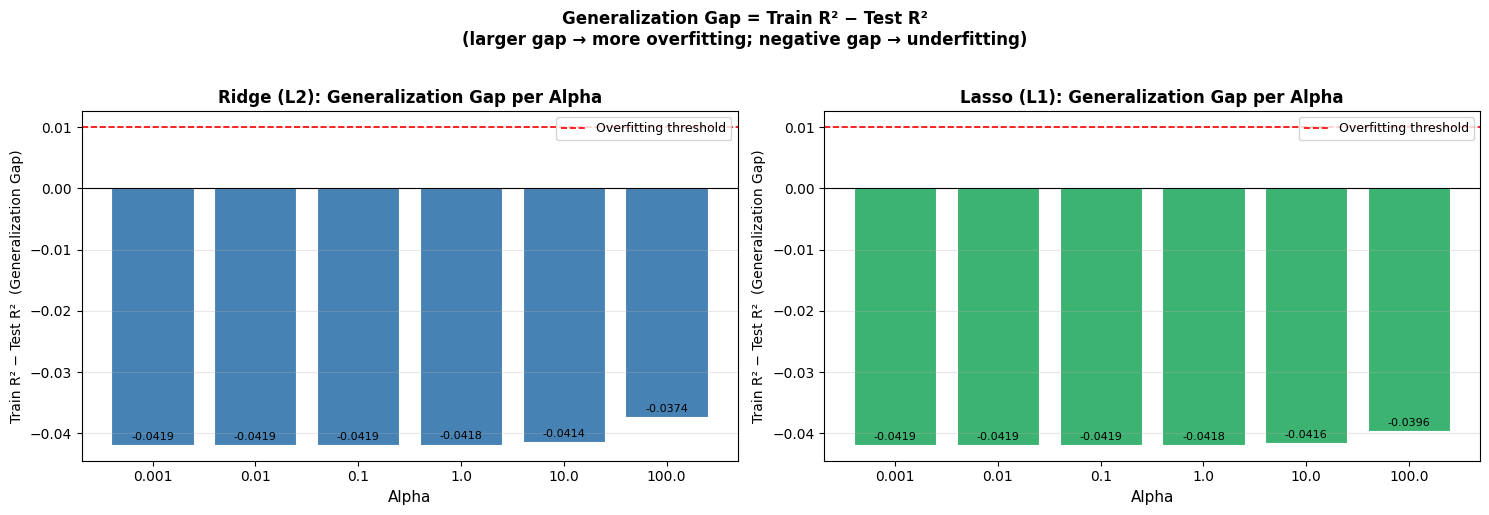

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, df_res, label, color in [
    (axes[0], ridge_df, 'Ridge (L2)', 'steelblue'),
    (axes[1], lasso_df, 'Lasso (L1)', 'mediumseagreen'),
]:
    gap = df_res['Train R²'] - df_res['Test R²']
    bars = ax.bar(
        [str(a) for a in df_res['Alpha']],
        gap,
        color=[('tomato' if g > 0.01 else color) for g in gap],
        edgecolor='white', linewidth=0.8
    )
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(0.01, color='red', lw=1.2, ls='--', label='Overfitting threshold')
    ax.set_xlabel('Alpha', fontsize=11)
    ax.set_ylabel('Train R² − Test R²  (Generalization Gap)', fontsize=10)
    ax.set_title(f'{label}: Generalization Gap per Alpha', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for bar, g in zip(bars, gap):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{g:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Generalization Gap = Train R² − Test R²\n'
             '(larger gap → more overfitting; negative gap → underfitting)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Final Summary — Best Generalization per Model

In [17]:
print('=' * 65)
print('EXPERIMENT 1 — FINAL SUMMARY')
print('=' * 65)

for label, df_res, best_idx in [
    ('Ridge (L2)', ridge_df, best_ridge_idx),
    ('Lasso (L1)', lasso_df, best_lasso_idx),
]:
    row = df_res.loc[best_idx]
    print(f'\n{label}')
    print(f'  Best Alpha   : {row["Alpha"]}')
    print(f'  Train R²     : {row["Train R²"]:.4f}')
    print(f'  Test R²      : {row["Test R²"]:.4f}')
    print(f'  Test MSE     : ${row["Test MSE"]:,.2f}')
    print(f'  Test MAE     : ${row["Test MAE"]:,.2f}')

print('\n' + '=' * 65)

# Full tables
print('\nRidge — all results:')
print(ridge_df[['Alpha','Train R²','Test R²','||w|| (L2)']].to_string(index=False))
print('\nLasso — all results:')
print(lasso_df[['Alpha','Train R²','Test R²','||w|| (L1)','Non-zero coefs']].to_string(index=False))

EXPERIMENT 1 — FINAL SUMMARY

Ridge (L2)
  Best Alpha   : 0.001
  Train R²     : 0.7417
  Test R²      : 0.7836
  Test MSE     : $33,596,923.81
  Test MAE     : $4,181.20

Lasso (L1)
  Best Alpha   : 0.001
  Train R²     : 0.7417
  Test R²      : 0.7836
  Test MSE     : $33,596,920.07
  Test MAE     : $4,181.19


Ridge — all results:
  Alpha  Train R²  Test R²   ||w|| (L2)
  0.001  0.741726 0.783593 10443.991915
  0.010  0.741726 0.783592 10443.900665
  0.100  0.741726 0.783588 10442.988261
  1.000  0.741725 0.783541 10433.873334
 10.000  0.741658 0.783020 10343.625595
100.000  0.736050 0.773420  9522.532772

Lasso — all results:
  Alpha  Train R²  Test R²   ||w|| (L1)  Non-zero coefs
  0.001  0.741726 0.783593 16533.261669               8
  0.010  0.741726 0.783593 16533.123689               8
  0.100  0.741726 0.783590 16531.744011               8
  1.000  0.741725 0.783566 16517.949251               8
 10.000  0.741715 0.783320 16382.367992               7
100.000  0.741067 0.780632

---
## Discussion — Expected Insights

### Q1: What happens when regularization is too weak (small α)?

At very small alpha values (e.g. α = 0.001), the penalty on coefficient size is negligible — the model behaves almost identically to ordinary Linear Regression. The coefficient norm ‖w‖ is large, meaning the model freely adjusts weights to fit the training data. This can lead to **high variance (overfitting)**: the model captures noise in the training set and performs slightly worse on unseen test data, visible as a positive Train R² − Test R² gap.

### Q2: What happens when regularization is too strong (large α)?

At large alpha values (e.g. α = 100), the penalty dominates the loss function. Coefficients are crushed toward zero regardless of their true predictive value. The model becomes too simple to capture real patterns in the data — this is **high bias (underfitting)**. Both Train R² and Test R² drop, and the Train–Test gap may close or even reverse (Test R² > Train R²), since the model is so constrained it barely fits training data either.

### Q3: Which alpha gives the best generalization?

An intermediate alpha (typically in the range 0.01–1 for this dataset) provides the **best bias–variance tradeoff** — it penalizes unnecessarily large coefficients without destroying genuine feature signals. This sweet spot is where Test R² is maximized and the generalization gap is minimized.

### Q4: Ridge vs Lasso — key differences

| Property | Ridge (L2) | Lasso (L1) |
|---|---|---|
| Penalty term | ∑ wᵢ² | ∑ |wᵢ| |
| Coefficient behavior | Shrinks all toward 0, never zero | Can zero out weak features exactly |
| Feature selection | No | Yes (automatic) |
| Best for | Many small/medium effects | Sparse models, irrelevant features |

In this insurance dataset, `smoker` dominates the prediction. Lasso at moderate alpha correctly retains it while zeroing region dummy variables, confirming that geographic region adds little predictive value for charges.

### Conclusion — Bias–Variance Tradeoff

This experiment directly demonstrates the **bias–variance tradeoff**:

- **Weak regularization** (small α) → low bias, high variance → overfits training data
- **Strong regularization** (large α) → high bias, low variance → underfits all data
- **Optimal regularization** (intermediate α) → balanced bias and variance → best generalization

The goal of regularization is not to maximize training performance, but to find the model that generalizes best to unseen data — and the alpha sweep experiment makes this tradeoff visually and numerically clear.